### Как запускать программу

Программа запускается в терминале следующим образом (где число N = 4 - это размер сетки, а р = 5 - это параметр из условия задачи, т.е. константа ): 

Сначала пишется команда ```make clean``` (для очистки ненужных файлов типа .o)

После идет команда в терминале ```make```

И в конце пишем в терминале ```./a.out 4 5```

Если что-то в программе изменилось, или есть необходимость удалить ненужные файлы, то нужно использовать команду make clean, после ```make``` и в конце ```./a.out 4 5```

Как выбирать различные функции: необходимо открыть файл task_1.cpp и в самом начале найти функцию double f(double x) (на 3-ей строчке кода), и уже выбрать из закомментированных функций какую использовать (можно и добавить еще функции при необходимости):

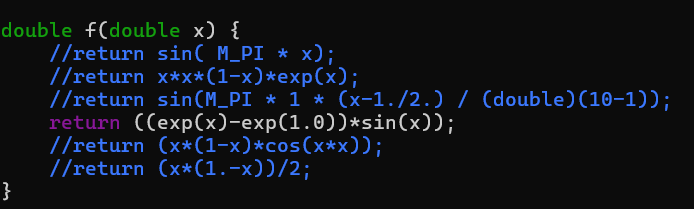

Примеры запуска программы на конкретных функциях (все 3 случая запускаем следующим образом ```./a.out 4 5```):

1) Функция $f = (x \cdot (1 - x)) \cos(x^2)$ (данная функция удовлетворяет краевым условиям задачи f(0) = f(1) = 0). Результат данного запуска записывается в файле output.txt, этот результат можно посмотреть, написав команду в терминале ```cat output.txt```:

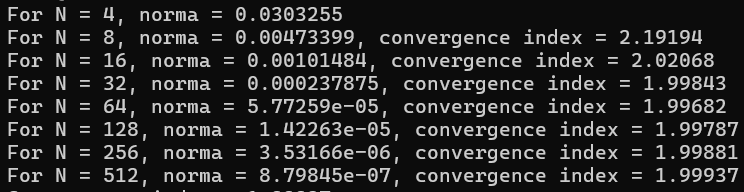

А это то, что печатается и выводится в консоли:

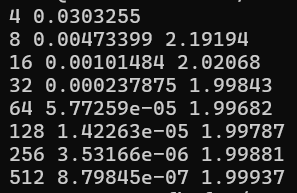

2) Базисная функция $f = \sin(\pi \cdot (x - 0.5) / 9)$. Результат данного запуска записывается в файле output.txt, этот результат можно посмотреть, написав команду в терминале ```cat output.txt```:

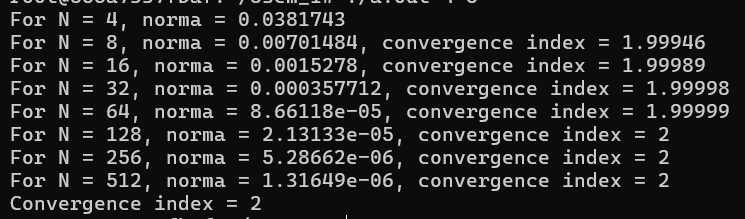

А это то, что печатается и выводится в консоли:

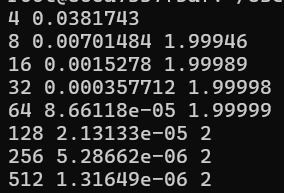

3) Функция $(e^{x} - e) \cdot \sin{x}$ (данная функция удовлетворяет краевым условиям задачи f(0) = f(1) = 0). Результат данного запуска записывается в файле output.txt, этот результат можно посмотреть, написав команду в терминале ```cat output.txt```:

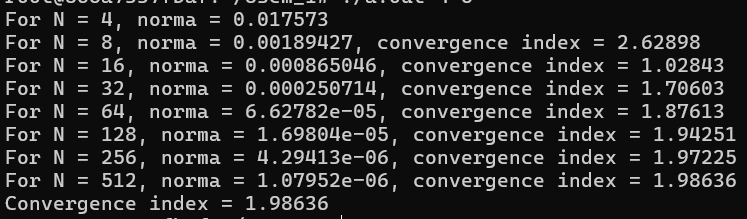

А это то, что печатается и выводится в консоли:

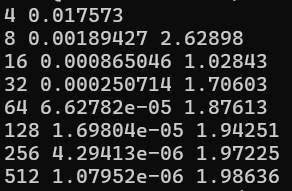

В файле ```output.txt```:

1-ый столбец соответствует числу N

2-ой столбец - ошибкам/невязкам для различных N из 1-ого столбца

3-ий столбец - показателям сходимости для различных N из 1-ого столбца

### Вычисление ошибки

Для системы вычисляется норма невязки ($L_2$-норма невязки как корень корень из суммы квадратов невязок, т.е. для каждого элемента находит разницу между вектором правой части b и полученным вектором Ax), т.е.

${error} = \sqrt{h \cdot \sum_{k=0}^{N-1} (b_i − (Ax)_i)^2}$

### График для анализа показателя сходимости (с помощью Python)

Размер сетки = 4, погрешность = 0.0687254
Размер сетки = 8, погрешность = 0.0204464, показатель сходимости = 1.4308
Размер сетки = 16, погрешность = 0.00526993, показатель сходимости = 1.77893
Размер сетки = 32, погрешность = 0.00132554, показатель сходимости = 1.90126
Размер сетки = 64, погрешность = 0.000331785, показатель сходимости = 1.95318
Размер сетки = 128, погрешность = 8.29616e-05, показатель сходимости = 1.97718
Размер сетки = 256, погрешность = 2.07403e-05, показатель сходимости = 1.98873
Размер сетки = 512, погрешность = 5.18493e-06, показатель сходимости = 1.9944


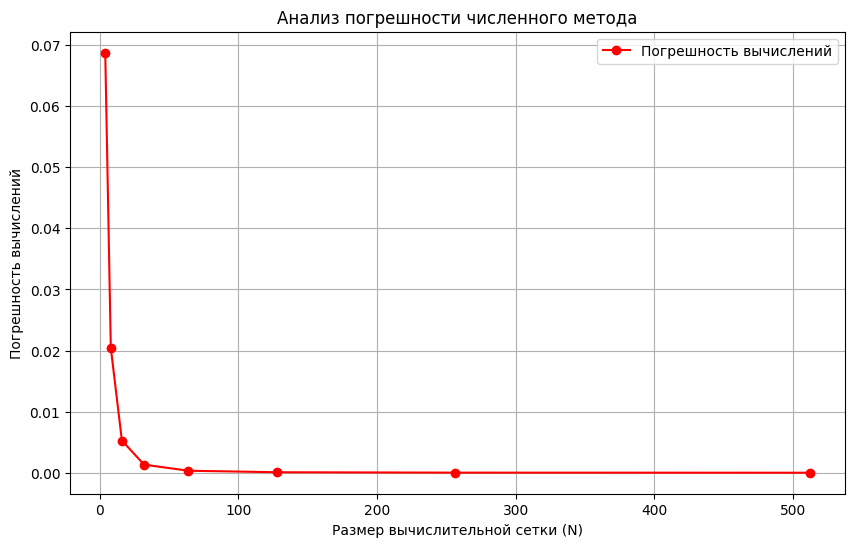

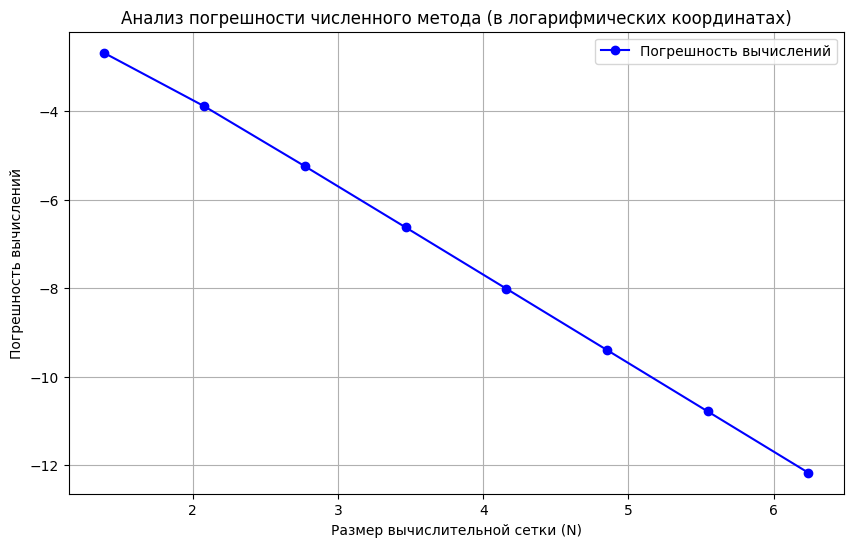

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def process_data_file(file_path):
    sizes, errors, rates = [], [], []
    
    with open(file_path, 'r') as data_source:
        for record in data_source:
            if not record.strip():
                continue
                
            parts = record.split()
        
            if len(parts) == 2:
                size = int(float(parts[0]))
                error = float(parts[1])
                sizes.append(size)
                errors.append(error)
                print(f"Размер сетки = {size}, погрешность = {error}")
            
            elif len(parts) == 3:
                size = int(float(parts[0]))
                error = float(parts[1])
                rates = float(parts[2])
                sizes.append(size)
                errors.append(error)
                print(f"Размер сетки = {size}, погрешность = {error}, показатель сходимости = {rates}")

            else: continue
        
    return sizes, errors, rates

def create_visualization(grid_dimensions, error_metrics):

    plt.figure(figsize=(10, 6))  
    plt.plot(grid_dimensions, error_metrics, marker='o', linestyle='-', color='r', label='Погрешность вычислений')  
    plt.xlabel('Размер вычислительной сетки (N)')  
    plt.ylabel('Погрешность вычислений')  
    plt.title('Анализ погрешности численного метода')  
    plt.grid(True) 
    plt.legend()
    plt.savefig('1.png')
    plt.show()

    plt.figure(figsize=(10, 6))  
    plt.plot(np.log(grid_dimensions), np.log(error_metrics), marker='o', linestyle='-', color='b', label='Погрешность вычислений')  
    plt.xlabel('Размер вычислительной сетки (N)')  
    plt.ylabel('Погрешность вычислений')  
    plt.title('Анализ погрешности численного метода (в логарифмических координатах)')  
    plt.grid(True) 
    plt.legend()
    plt.show()


input_file = "output.txt"
mesh_sizes, calculation_errors, convergence_rates = process_data_file(input_file)
create_visualization(mesh_sizes, calculation_errors)